## EDA

### Repetition

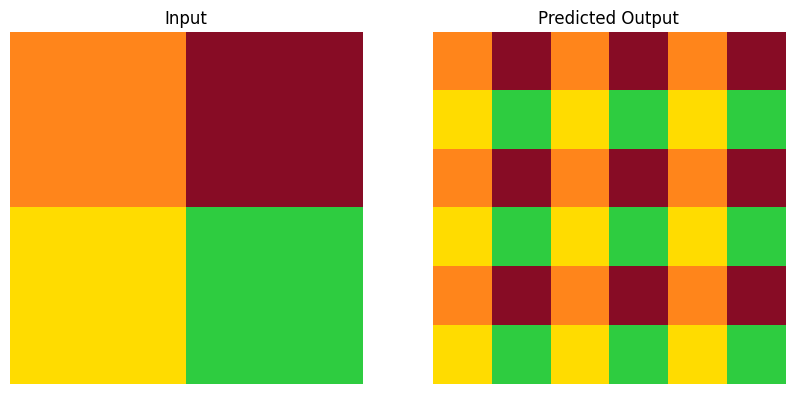

In [47]:
import os
import sys
import importlib
import utils
import solver
import matplotlib.pyplot as plt
import numpy as np

#(Force Reload)
importlib.reload(utils)
importlib.reload(solver)

# এখন ইমপোর্ট করুন
from utils import load_arc_data, plot_grid, find_objects
from solver import repeat_pattern, translate_object, rotate_grid, flip_grid, master_solver
from pathlib import Path
sys.path.append(os.path.abspath('../src'))


data_dir = Path("../data")
challenges = load_arc_data(data_dir / 'arc-agi_training_challenges.json')

# Selecting a task
task_id = '00576224' 
input_grid = challenges[task_id]['train'][0]['input']

# Trying the solver
prediction = repeat_pattern(input_grid, 3)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plot_grid(input_grid, "Input")
plt.subplot(1, 2, 2); plot_grid(prediction, "Predicted Output")
plt.show()

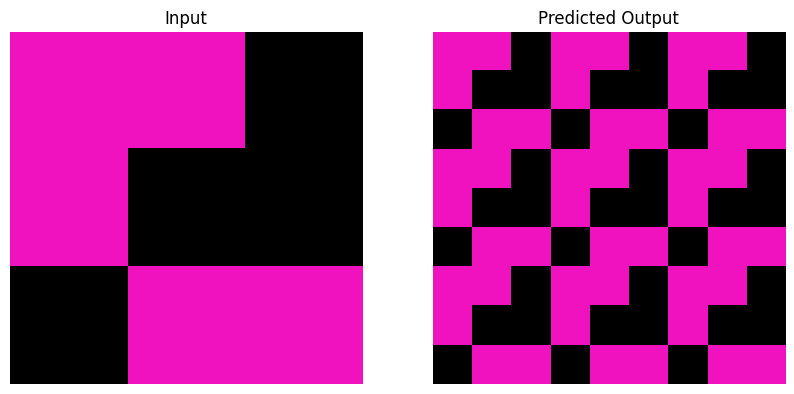

In [48]:
# Selecting a task
task_id = '007bbfb7' 
input_grid = challenges[task_id]['train'][0]['input']

# Trying the solver
prediction = repeat_pattern(input_grid, 3)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plot_grid(input_grid, "Input")
plt.subplot(1, 2, 2); plot_grid(prediction, "Predicted Output")
plt.show()

#### Object Manipulation

In [49]:
task_id = '007bbfb7'
input_grid = challenges[task_id]['train'][0]['input']

found_objects = find_objects(input_grid)

print(f"Task ID: {task_id}")
print(f"Number of objects found: {len(found_objects)}")

Task ID: 007bbfb7
Number of objects found: 2


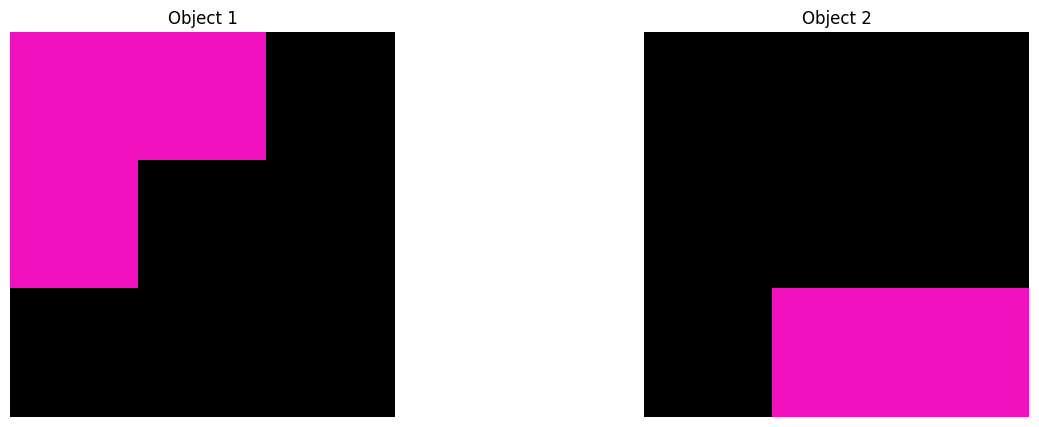

In [50]:

plt.figure(figsize=(15, 5))
for i, coords in enumerate(found_objects):
    # create an empty grid for the object
    obj_grid = np.zeros_like(input_grid)
    # only place the pixels belonging to that object
    for r, c in coords:
        obj_grid[r, c] = input_grid[r][c]
    
    plt.subplot(1, len(found_objects), i+1)
    plot_grid(obj_grid, f"Object {i+1}")
plt.show()

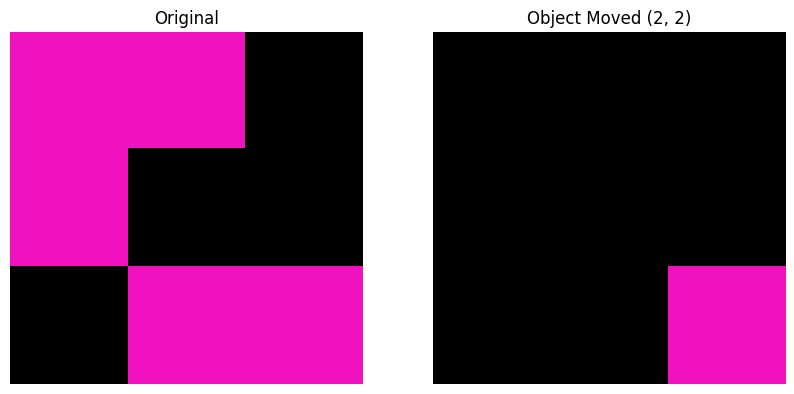

In [51]:
found_objects = find_objects(input_grid)

first_obj_coords = found_objects[0]

# dr=2 (২ ঘর নিচে), dc=2 (২ ঘর ডানে)
moved_grid = translate_object(input_grid, first_obj_coords, dr=2, dc=2)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plot_grid(input_grid, "Original")
plt.subplot(1, 2, 2); plot_grid(moved_grid, "Object Moved (2, 2)")
plt.show()

#### Symmetry, Rotation, and Reflection

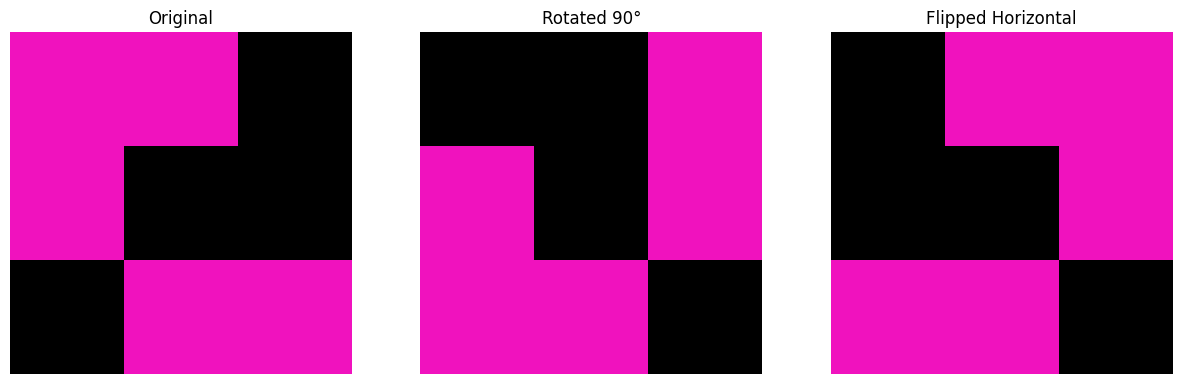

In [52]:
# গ্রিডটিকে ৯০ ডিগ্রি ঘোরানো
rotated = rotate_grid(input_grid, k=1)

# গ্রিডটিকে ডানে-বামে ফ্লিপ করা
flipped = flip_grid(input_grid, axis=1)

# ভিজ্যুয়ালাইজেশন
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plot_grid(input_grid, "Original")
plt.subplot(1, 3, 2); plot_grid(rotated, "Rotated 90°")
plt.subplot(1, 3, 3); plot_grid(flipped, "Flipped Horizontal")
plt.show()

#### The "Brute Force" Solver (মাস্টার ফাংশন)

Success! Found winning logic: Kronecker Product


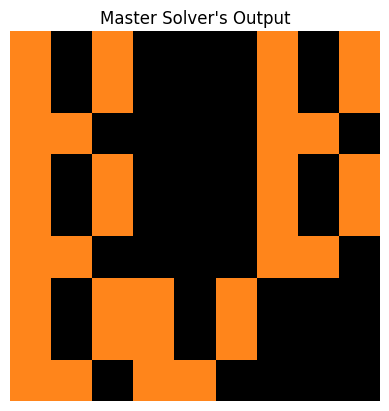

In [ ]:
task_data = challenges['007bbfb7']
train_examples = task_data['train']
test_input = task_data['test'][0]['input']

final_prediction = master_solver(train_examples, test_input)

if isinstance(final_prediction, list):
    plot_grid(final_prediction, "Master Solver's Output")
else:
    print(final_prediction)